# Lorenz 96: Exploratory Data Analysis & Baselines
This notebook explores the generated dataset, visualizes chaotic trajectories and correlations, and evaluates two baselines for multivariate forecasting: Persistence and Ridge Regression.

In [ ]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the working directory is the project root
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append('.')

from src.prepare_windows import create_windows
from src.baselines import persistence_forecast, train_linear_forecast, predict_linear_forecast, evaluate_metrics

## 1. Data Loading and Trajectory Visualization

Train set shape: (12000, 40)
Validation set shape: (4000, 40)
Test set shape: (4000, 40)


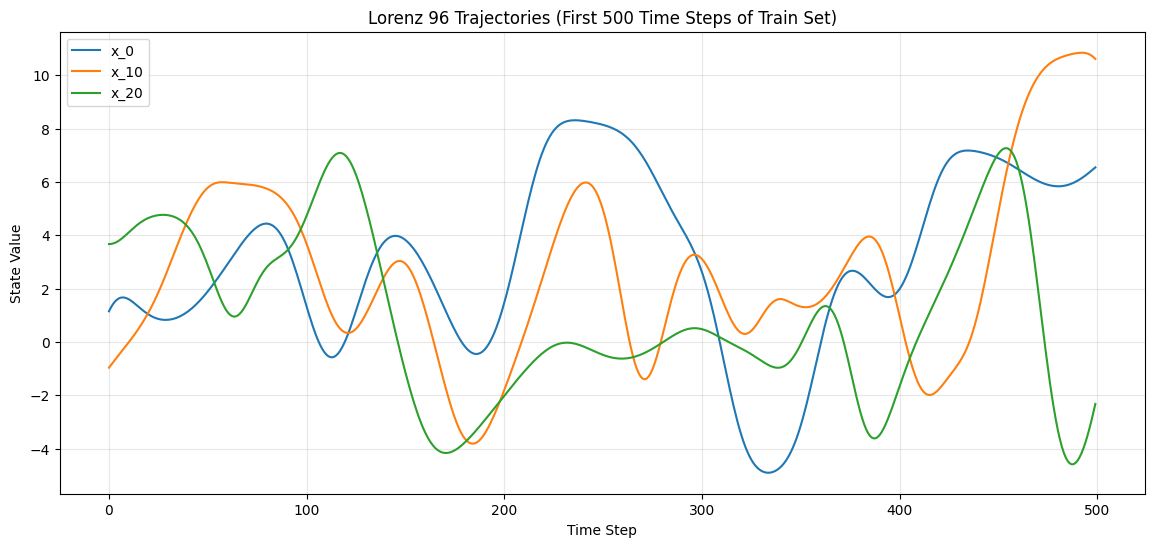

In [ ]:
train_data = np.load('data/train.npy')
val_data = np.load('data/val.npy')
test_data = np.load('data/test.npy')

print(f"Train set shape: {train_data.shape}")
print(f"Validation set shape: {val_data.shape}")
print(f"Test set shape: {test_data.shape}")

plt.figure(figsize=(14, 6))
plt.plot(train_data[:500, 0], label='x_0')
plt.plot(train_data[:500, 10], label='x_10')
plt.plot(train_data[:500, 20], label='x_20')
plt.title('Lorenz 96 Trajectories (First 500 Time Steps of Train Set)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Spatial Correlations

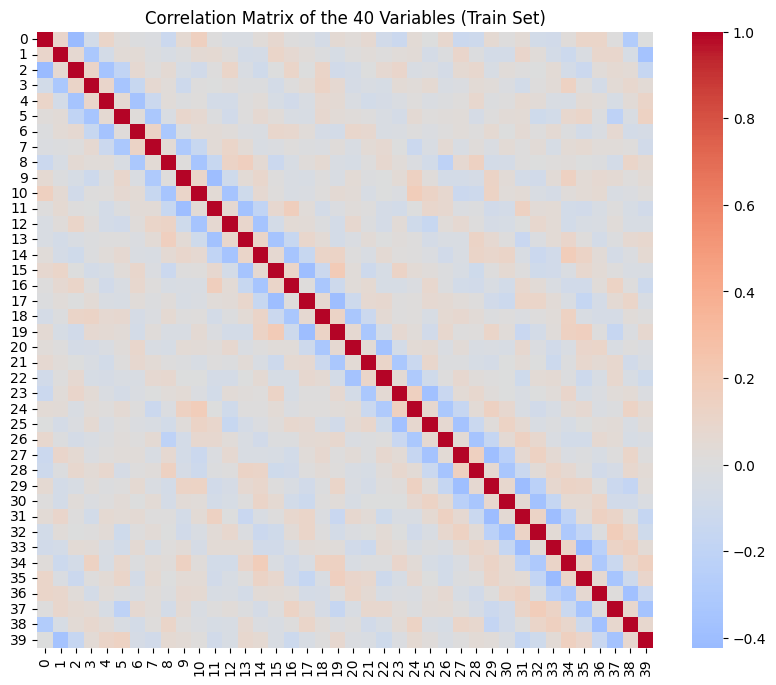

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = np.corrcoef(train_data.T)
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of the 40 Variables (Train Set)')
plt.show()

### Discussion of Chaotic Behavior
The Lorenz 96 model demonstrates high spatio-temporal chaos. Looking at the trajectory plots, the variables fluctuate with irregular frequencies and amplitudes, a hallmark of chaotic systems sensitive to initial conditions. 

Furthermore, the correlation matrix shows distinct local correlation bands parallel to the diagonal. Because the system's differential equations couple a variable $x_i$ strictly with its immediate neighbors ($x_{i-2}, x_{i-1}, x_{i+1}$), we observe strong short-range spatial relationships. However, variables positioned further away in the spatial "ring" exhibit near-zero linear correlation over time, highlighting the complex, non-linear mixing of information across the system.

## 3. Forecasting Task Preparation

In [ ]:
L = 10  # Window size
X_train, y_train = create_windows(train_data, L)
X_val, y_val = create_windows(val_data, L)
X_test, y_test = create_windows(test_data, L)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (11990, 10, 40), y_train shape: (11990, 40)
X_test shape:  (3990, 10, 40), y_test shape:  (3990, 40)


## 4. Baseline Evaluation

In [ ]:
# Persistence Baseline
y_pred_pers = persistence_forecast(X_test)
metrics_pers = evaluate_metrics(y_test, y_pred_pers)

print("--- Persistence Baseline ---")
print(f"Average MSE: {metrics_pers['avg_mse']:.4f}")
print(f"Average MAE: {metrics_pers['avg_mae']:.4f}\n")

# Ridge Regression Baseline
model_ridge = train_linear_forecast(X_train, y_train, alpha=1.0)
y_pred_ridge = predict_linear_forecast(model_ridge, X_test)
metrics_ridge = evaluate_metrics(y_test, y_pred_ridge)

print("--- Ridge Regression Baseline ---")
print(f"Average MSE: {metrics_ridge['avg_mse']:.4f}")
print(f"Average MAE: {metrics_ridge['avg_mae']:.4f}")

--- Persistence Baseline ---
Average MSE: 0.0344
Average MAE: 0.1364

--- Ridge Regression Baseline ---
Average MSE: 0.0001
Average MAE: 0.0057


C:\Users\Ameya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.23871e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [ ]:
os.makedirs('results', exist_ok=True)

results_dict = {
    'persistence': metrics_pers,
    'ridge': metrics_ridge
}

with open('results/baseline_metrics.json', 'w') as f:
    json.dump(results_dict, f, indent=4)

print("Metrics successfully saved to results/baseline_metrics.json")

Metrics successfully saved to results/baseline_metrics.json
